BATTINGEDGE V9.5 - TRAINING STACKING ENSEMBLE

📂 Loading data...
   Val Set:  388 samples (Used for Meta-Training)
   Test Set: 378 samples (Used for Final Eval)

🏗️  Loading base models...


d:\Users\Anoshia\BattingEdge_FYP\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


   ✅ Loaded LSTM
   ✅ Loaded XGBoost
   ✅ Loaded Random Forest

🔮 Generating meta-features (Probabilities)...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished


   Meta-Feature Shape: (388, 15) (Combined Probabilities)

🧠 Training Meta-Learner (Stacking)...
   ✅ Meta-Model Trained.

📊 STACKED ENSEMBLE RESULTS

🏆 STACKED ACCURACY: 94.71%

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Cover Drive      0.986     0.885     0.932        78
    Cut Shot      0.895     0.951     0.922        81
     Defense      1.000     0.973     0.986        75
   Pull Shot      0.957     0.930     0.943        71
  Sweep Shot      0.912     1.000     0.954        73

    accuracy                          0.947       378
   macro avg      0.950     0.948     0.948       378
weighted avg      0.950     0.947     0.947       378

🔢 CONFUSION MATRIX:
         Cove  Cut   Defe  Pull  Swee
Cover Dr   69     4     0     2     3
Cut Shot    1    77     0     1     2
Defense     0     1    73     0     1
Pull Sho    0     4     0    66     1
Sweep Sh    0     0     0     0    73

📈 PER-CLASS ACCURACY:
   Cover Drive    :  69/ 78 =  88.5%

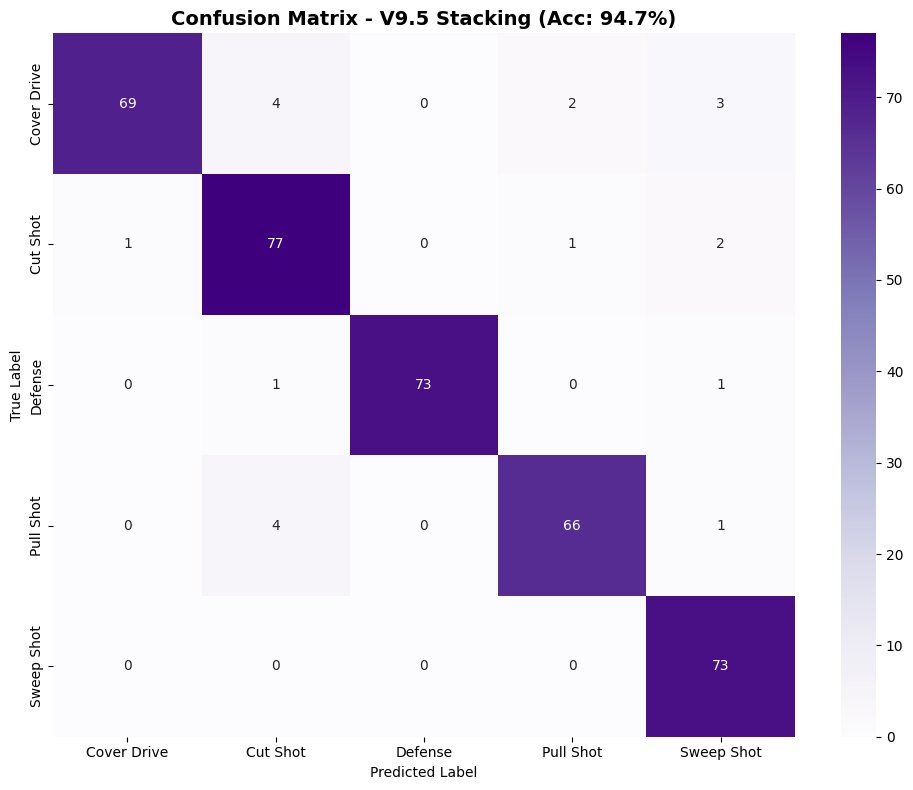

In [2]:
# ============================================================
# BattingEdge V9.5 - STACKING ENSEMBLE (Trainable)
# Logic: Trains a Meta-Model (Logistic Regression) to learn 
#        optimal weights for combining LSTM + RF + XGBoost
# ============================================================

import numpy as np
import pickle
from pathlib import Path
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

# Model Imports
import tensorflow as tf
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# ================= CONFIG =================
FEATURE_DIR = Path(r"D:\Users\Anoshia\BattingEdge_FYP\features")
MODEL_DIR   = Path(r"D:\Users\Anoshia\BattingEdge_FYP\backend\models")

# We use the VALIDATION set to train the Meta-Model
MODEL_FILES = {
    "lstm": "battingedge_V9_5_best.keras",
    "xgboost": "battingedge_V9_5_xgboost_best.json",
    "rf": "battingedge_V9_5_random_forest_best.pkl"
}
# ==========================================

print("="*70)
print("BATTINGEDGE V9.5 - TRAINING STACKING ENSEMBLE")
print("="*70)
print()

# ================= 1. LOAD DATA =================
print("📂 Loading data...")

try:
    # We need Val set (to train meta-model) and Test set (to evaluate)
    X_val   = np.load(FEATURE_DIR / "X_val.npy")
    y_val   = np.load(FEATURE_DIR / "y_val.npy")
    X_test  = np.load(FEATURE_DIR / "X_test.npy")
    y_test  = np.load(FEATURE_DIR / "y_test.npy")

    with open(FEATURE_DIR / "classes.pkl", "rb") as f:
        CLASSES = pickle.load(f)
    
    # Load Scaler
    scaler = joblib.load(MODEL_DIR / "scaler_V9_5.pkl")
    
    # PREPARE DATA SHAPES
    N_val, T, F = X_val.shape
    N_test = X_test.shape[0]

    # 1. Scale Data
    X_val_scaled_3d  = scaler.transform(X_val.reshape(N_val*T, F)).reshape(N_val, T, F)
    X_test_scaled_3d = scaler.transform(X_test.reshape(N_test*T, F)).reshape(N_test, T, F)

    # 2. Flatten for RF/XGB (N, 5350)
    X_val_flat  = X_val_scaled_3d.reshape(N_val, -1)
    X_test_flat = X_test_scaled_3d.reshape(N_test, -1)

    print(f"   Val Set:  {X_val.shape[0]} samples (Used for Meta-Training)")
    print(f"   Test Set: {X_test.shape[0]} samples (Used for Final Eval)")

except Exception as e:
    print(f"\n❌ Error loading data: {e}")
    exit()

print()

# ================= 2. LOAD BASE MODELS =================
print("🏗️  Loading base models...")

models = {}

# Load LSTM
try:
    models["lstm"] = tf.keras.models.load_model(str(MODEL_DIR / MODEL_FILES["lstm"]))
    print(f"   ✅ Loaded LSTM")
except:
    print(f"   ⚠️  Failed to load LSTM")

# Load XGBoost
try:
    xgb = XGBClassifier()
    xgb.load_model(MODEL_DIR / MODEL_FILES["xgboost"])
    models["xgboost"] = xgb
    print(f"   ✅ Loaded XGBoost")
except:
    print(f"   ⚠️  Failed to load XGBoost")

# Load Random Forest
try:
    models["rf"] = joblib.load(MODEL_DIR / MODEL_FILES["rf"])
    print(f"   ✅ Loaded Random Forest")
except:
    print(f"   ⚠️  Failed to load Random Forest")

print()

# ================= 3. GENERATE META-FEATURES =================
print("🔮 Generating meta-features (Probabilities)...")

def get_meta_features(X_3d, X_flat):
    meta_features = []
    
    # LSTM Probs
    if "lstm" in models:
        p1 = models["lstm"].predict(X_3d, verbose=0)
        meta_features.append(p1)
    
    # XGB Probs
    if "xgboost" in models:
        p2 = models["xgboost"].predict_proba(X_flat)
        meta_features.append(p2)
        
    # RF Probs
    if "rf" in models:
        p3 = models["rf"].predict_proba(X_flat)
        meta_features.append(p3)
    
    # Concatenate
    return np.hstack(meta_features)

# Train Set for Meta-Model (From Validation Data)
X_meta_train = get_meta_features(X_val_scaled_3d, X_val_flat)
y_meta_train = y_val

# Test Set for Meta-Model (From Test Data)
X_meta_test = get_meta_features(X_test_scaled_3d, X_test_flat)
y_meta_test = y_test

print(f"   Meta-Feature Shape: {X_meta_train.shape} (Combined Probabilities)")
print()

# ================= 4. TRAIN META-MODEL =================
print("🧠 Training Meta-Learner (Stacking)...")

# ✅ FIX: Removed 'multi_class' parameter which caused the error
meta_model = LogisticRegression(max_iter=1000)

meta_model.fit(X_meta_train, y_meta_train)

print("   ✅ Meta-Model Trained.")
print()

# ================= 5. EVALUATION =================
print("="*70)
print("📊 STACKED ENSEMBLE RESULTS")
print("="*70)
print()

# Predict using the trained meta-model
y_pred_stack = meta_model.predict(X_meta_test)

# Accuracy
acc = accuracy_score(y_meta_test, y_pred_stack) * 100
print(f"🏆 STACKED ACCURACY: {acc:.2f}%")
print()

# Classification Report
print("📋 CLASSIFICATION REPORT:")
report = classification_report(y_meta_test, y_pred_stack, target_names=CLASSES, digits=3)
print(report)

with open(MODEL_DIR / "report_V9_5_stacking.txt", "w") as f:
    f.write(report)

# Confusion Matrix
cm = confusion_matrix(y_meta_test, y_pred_stack)
print("🔢 CONFUSION MATRIX:")
print("        ", "  ".join([f"{cls[:4]:>4s}" for cls in CLASSES]))
for i, cls in enumerate(CLASSES):
    print(f"{cls[:8]:8s}", "  ".join([f"{cm[i,j]:4d}" for j in range(len(CLASSES))]))
print()

# Per-class Accuracy
print("📈 PER-CLASS ACCURACY:")
for i, cls in enumerate(CLASSES):
    correct = cm[i, i]
    total = cm[i, :].sum()
    acc_cls = (correct / total * 100) if total > 0 else 0
    print(f"   {cls:15s}: {correct:3d}/{total:3d} = {acc_cls:5.1f}%")

print()

# Visualizations
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f"Confusion Matrix - V9.5 Stacking (Acc: {acc:.1f}%)", fontsize=14, fontweight='bold')
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(MODEL_DIR / "confusion_matrix_V9_5_stacking.png", dpi=300)
print("✅ Saved: confusion_matrix_V9_5_stacking.png")

# Save the Meta-Model
joblib.dump(meta_model, MODEL_DIR / "battingedge_V9_5_meta_model.pkl")
print(f"💾 Saved Meta-Model: battingedge_V9_5_meta_model.pkl")

# Save Metadata
metadata = {
    "version": "V9.5 Stacking",
    "base_models": list(models.keys()),
    "meta_learner": "LogisticRegression",
    "test_accuracy": acc,
    "per_class_accuracy": {
        CLASSES[i]: float((cm[i,i] / cm[i,:].sum() * 100) if cm[i,:].sum() > 0 else 0)
        for i in range(len(CLASSES))
    }
}

with open(MODEL_DIR / "metadata_V9_5_stacking.json", "w") as f:
    json.dump(metadata, f, indent=2)

print()
print("="*70)
print("🎉 STACKING COMPLETE")
print("="*70)